In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from pathlib import Path
import numpy as np

%matplotlib inline

## 1. Best Model Finding Strategy


In [16]:
# ================= CONFIGURATION =================
METRIC = 'rollout/ep_rew_mean' 
SMOOTHING = 0.5
OUTPUT_SUMMARY = "experiment_records.csv"
OUTPUT_STABLE = "stable_champions_data.csv"
CHECKPOINT_INTERVAL = 5000 
# =================================================

The `extract_all_data` function recursively scans a root directory to locate all TensorBoard event files and extracts scalar training metrics from each log. Metadata such as experiment group architecture seed and unique run identifiers are inferred from the directory structure while optional exponential smoothing is applied to reduce metric noise. The extracted timesteps rewards and associated metadata are aggregated into a unified Pandas DataFrame to support downstream analysis and model

In [17]:
def extract_all_data(root_dir):
    log_files = glob.glob(os.path.join(root_dir, "**", "*tfevents*"), recursive=True)
    all_records = []
    print(f"Reading {len(log_files)} logs...")
    for log_path in log_files:
        try:
            parts = os.path.normpath(log_path).split(os.sep)
            arch_name = parts[-4] if len(parts) >= 4 else "Unknown_Arch"
            seed_name = parts[-3] if len(parts) >= 3 else "Unknown_Seed"
            group_name = parts[-5] if len(parts) >= 5 else "Experiment"
            ea = EventAccumulator(log_path, size_guidance={'scalars': 0}); ea.Reload()
            if METRIC not in ea.Tags()['scalars']: continue
            events = ea.Scalars(METRIC)
            steps = [e.step for e in events]; values = [e.value for e in events]
            smoothed = []
            if SMOOTHING > 0:
                last = values[0]
                for v in values:
                    last = last * SMOOTHING + (1 - SMOOTHING) * v
                    smoothed.append(last)
            else: smoothed = values
            for s, v in zip(steps, smoothed):
                all_records.append({"Timesteps": s, "Reward": v, "Group": group_name, 
                                    "Architecture": arch_name, "Seed": seed_name, 
                                    "ID": f"{group_name}_{arch_name}_{seed_name}", "Full_Path": log_path})
        except Exception as e: print(f"Error: {e}")
    return pd.DataFrame(all_records)


Here a transition beyond simple maximum reward tracking is performed to prioritize **policy stability**. Performance fluctuation is often observed due to high gradient variance or catastrophic forgetting therefore the optimal model is identified by calculating a score over a rolling window of timesteps.  
Fitness is defined as $ F = \mu - \sigma $ where $ \mu $ denotes the mean episodic return and $\sigma$ denotes the standard deviation. A checkpoint located in a high reward low variance region of the optimization landscape is selected ensuring convergence to a stable local optimum rather than a transient performance spike.

Once the **Best Step** $ s^* $ is identified a nearest neighbor search is applied to map it to the closest physically saved checkpoint file satisfying the constraint

$
s_{\text{actual}} = \arg\min_{s \in C} \lvert s - s^* \rvert
$

where $ C $ represents the set of steps defined by the `CHECKPOINT_INTERVAL`. This procedure ensures that the model retrieved, represents the most mathematically reliable manifestation of the agent peak learned behavior.



In [18]:
def get_nearest_checkpoints(best_step, interval=5000):
    """Calculates a list of checkpoint steps to check, sorted by closeness to target."""
    nearest = int(round(best_step / interval) * interval)
    floor = int((best_step // interval) * interval)
    ceil = floor + interval
    # Unique steps sorted by absolute distance to the best_step
    return sorted(list(set([nearest, floor, ceil])), key=lambda x: abs(x - best_step))

def verify_checkpoint_path(log_path, best_step, interval=5000):
    abs_log_path = os.path.abspath(log_path)
    log_folder_dir = os.path.dirname(abs_log_path)
    seed_dir = os.path.dirname(log_folder_dir)
    
    search_locations = [
        seed_dir,
        os.path.join(seed_dir, "checkpoints"),
        os.path.join(seed_dir, "cheakpoints"), # Handling your typo folder
        os.path.join(seed_dir, "logs")
    ]
    
    steps_to_try = get_nearest_checkpoints(best_step, interval)
    
    for s in steps_to_try:
        # Pattern to find a zip containing that specific step number
        pattern = f"*{s}*.zip"
        for loc in search_locations:
            if not os.path.exists(loc): continue
            found = glob.glob(os.path.join(loc, pattern))
            if found:
                return found[0], s
                
    return "NOT_FOUND", None

def find_best_checkpoint_and_scan(df, window_size_steps=25000):
    best_checkpoints = []
    print(f"\n{'ID':<30} | {'TARGET':<10} | {'SELECTED CKPT':<15} | {'STATUS'}")
    print("-" * 85)

    for run_id, run_data in df.groupby("ID"):
        step_diffs = run_data['Timesteps'].diff().dropna()
        interval = step_diffs.iloc[0] if not step_diffs.empty else CHECKPOINT_INTERVAL
        
        window = int(window_size_steps // interval)
        run_data = run_data.copy()
        run_data['fitness'] = run_data['Reward'].rolling(window=window).mean() - \
                             run_data['Reward'].rolling(window=window).std()
        
        valid_data = run_data.dropna(subset=['fitness'])
        if valid_data.empty: continue
        best_row = valid_data.loc[valid_data['fitness'].idxmax()]
        
        target_step = best_row['Timesteps']
        full_file_path, actual_step = verify_checkpoint_path(best_row['Full_Path'], target_step, CHECKPOINT_INTERVAL)
        
        status = "FOUND" if full_file_path != "NOT_FOUND" else " MISSING"
        ckpt_name = os.path.basename(full_file_path) if full_file_path != "NOT_FOUND" else "N/A"

        print(f"{run_id[:30]:<30} | {int(target_step):<10,} | {str(actual_step):<15} | {status}")
        
        best_checkpoints.append({
            "ID": run_id, 
            "Target_Step": int(target_step),
            "Best_Step": actual_step if actual_step else int(target_step),
            "Reward": best_row['Reward'], 
            "Architecture": best_row['Architecture'],
            "Checkpoint_Path": full_file_path,
            "Checkpoint_Name": ckpt_name
        })

    return pd.DataFrame(best_checkpoints)

def filter_best_seeds(df):
    if df.empty: return df
    def calculate_fitness(group):
        tail = max(1, int(len(group) * 0.25))
        recent = group["Reward"].tail(tail)
        return recent.mean() - recent.std()
    run_stats = df.groupby("ID").apply(calculate_fitness, include_groups=False).reset_index(name="Fitness_Score")
    meta = df.groupby("ID")[["Group", "Architecture", "Seed", "Full_Path"]].first().reset_index()
    run_stats = pd.merge(run_stats, meta, on="ID")
    best_ids = []
    print("\n--- STABILITY-BASED SEED SELECTION ---")
    for _, config_group in run_stats.groupby(["Group", "Architecture"]):
        winner = config_group.loc[config_group["Fitness_Score"].idxmax()]
        best_ids.append(winner["ID"])
        print(f"{winner['Architecture']:<25} | {winner['Seed']:<10} | Score: {winner['Fitness_Score']:,.2f}")
    return df[df["ID"].isin(best_ids)]


In [19]:
parent_dir = Path.cwd().parent.parent
data = extract_all_data(parent_dir)
if not data.empty:
    champions_df = filter_best_seeds(data)
    best_ckpt_df = find_best_checkpoint_and_scan(champions_df)
    best_ckpt_df.to_csv("best_checkpoints_found.csv", index=False)
    print(f"\nFinal Deployment List saved to 'best_checkpoints_found.csv'")

Reading 4 logs...

--- STABILITY-BASED SEED SELECTION ---
Par_250000_1DCNN          | seed_1     | Score: 7,136.39
Par_250000_MLP            | seed_0     | Score: 7,458.86

ID                             | TARGET     | SELECTED CKPT   | STATUS
-------------------------------------------------------------------------------------
model_Par_250000_1DCNN_seed_1  | 222,720    | 225000          | FOUND
model_Par_250000_MLP_seed_0    | 245,120    | 245000          | FOUND

Final Deployment List saved to 'best_checkpoints_found.csv'


/tmp/ipykernel_25780/284300012.py:5: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.lineplot(


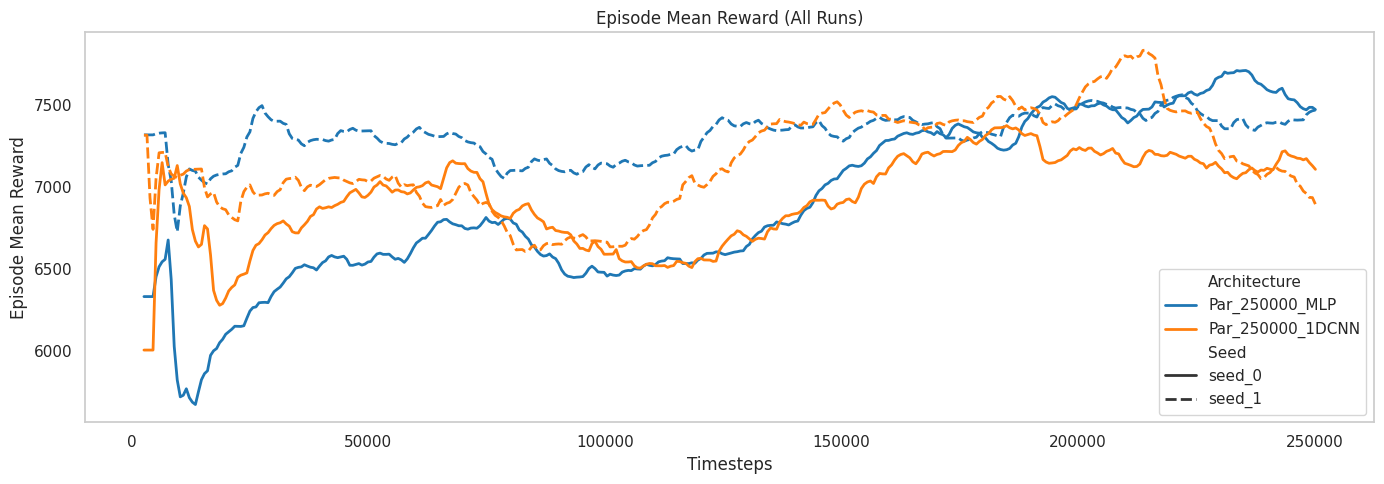

In [23]:
def plot_all_curves(df, output="ep_mean_reward_all_curves.png"):
    plt.figure(figsize=(14, 5))
    sns.set_theme(style="whitegrid")

    sns.lineplot(
        data=df,
        x="Timesteps",
        y="Reward",
        hue="Architecture",
        style="Seed",
        linewidth=2,
        palette=sns.color_palette("tab10", 5)   
    )

    plt.title("Episode Mean Reward (All Runs)")
    plt.xlabel("Timesteps")
    plt.ylabel("Episode Mean Reward")

    plt.tight_layout()
    plt.grid(False)
    plt.savefig(output, dpi=300)
    plt.show()

plot_all_curves(data)


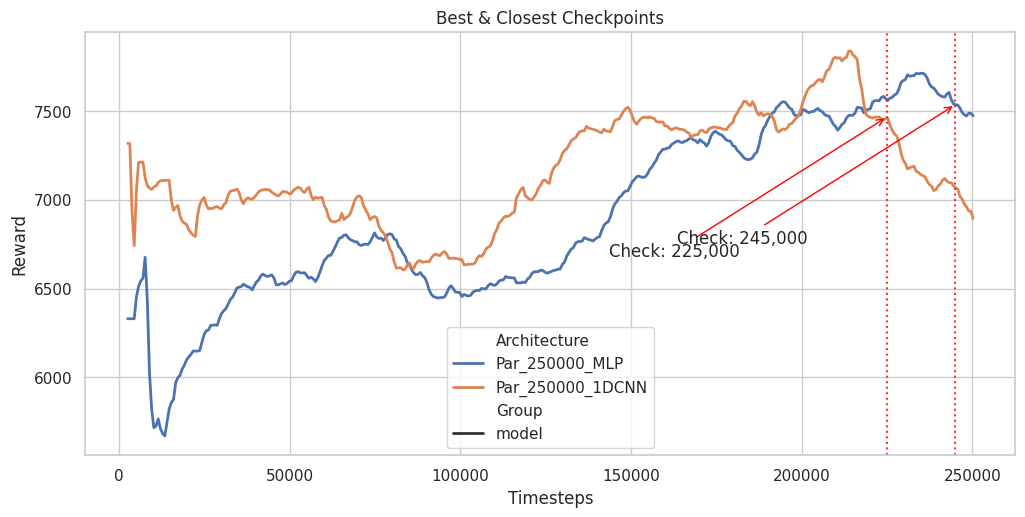

In [36]:
def plot_data(df, best_steps_df):
    plt.figure(figsize=(12, 5.5)); 
    sns.lineplot(data=df, x="Timesteps", y="Reward", hue="Architecture", style="Group", linewidth=2.0)

    for _, row in best_steps_df.iterrows():
        plt.axvline(x=row['Best_Step'], color='red', linestyle=':', alpha=0.8)
        plt.annotate(f"Check: {row['Best_Step']:,}", xy=(row['Best_Step'], row['Reward']), 
                     xytext=(-200, -100), textcoords='offset points', arrowprops=dict(arrowstyle='->', color='red'))
    
    plt.title("Best & Closest Checkpoints"); plt.savefig("stable_seed_comparison.png", dpi=300)
    
plot_data(champions_df, best_ckpt_df)

Then the best MLP, 1D-CNN and Baseline controllers are evaluated under multiple environmental conditions defined by variations in target heading and wind speed. Target headings of 95° 115° 135° and 145° fall within the interpolation regime where the reinforcement learning policies are expected to exhibit stable behavior and improved convergence speed relative to the Baseline. Headings at 85° and 145° lie slightly outside the training distribution representing extrapolation cases positioned 5° beyond the learned range and are included to assess whether performance degradation occurs gradually or exhibits abrupt failure when compared to the PID Baseline.

Wind speeds of 10 kt 14 kt and 18 kt correspond to conditions observed during training while 20 kt represents a stress test that exceeds the maximum trained wind intensity.  
Evaluation at 20 kt is used to determine whether the learned policies can generalize to higher aerodynamic loads and unobserved physical forces.Together these interpolation extrapolation and stress scenarios provide a structured assessment of robustness stability and generalization capability across architectures.

```{python}
python evaluate_1dcnnnew.py
python evaluate_mlpnew.py
python baseline_new.py
```



## 2. Model Performance Metrics

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### 2.1 Load Data

In [38]:
# --- Configuration ---
DATA_DIRS = {
    "MLP": Path("MLP"),
    "Baseline": Path("Baseline"),
    "1DCNN": Path("1DCNN")

}

# Set plot style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (5, 5)
sns.set_theme(style="whitegrid", font_scale=1.0)

### 2.2 Episode Vise CMG Analysis 

The agent's objective is to align its Course Made Good (CMG) with a desired target heading $\psi_{\text{ref}}$ despite external vector forces like wind or current. Mathematically the plot visualizes the evolution of the state variable $y_t$ (cmg) over time where the policy $\pi$ attempts to minimize the tracking error:

$
e(t) = \lvert \psi_{\text{ref}} - \phi_{\text{cmg}}(t) \rvert
$
  



Plot saved to cmg_comparison_plot.png


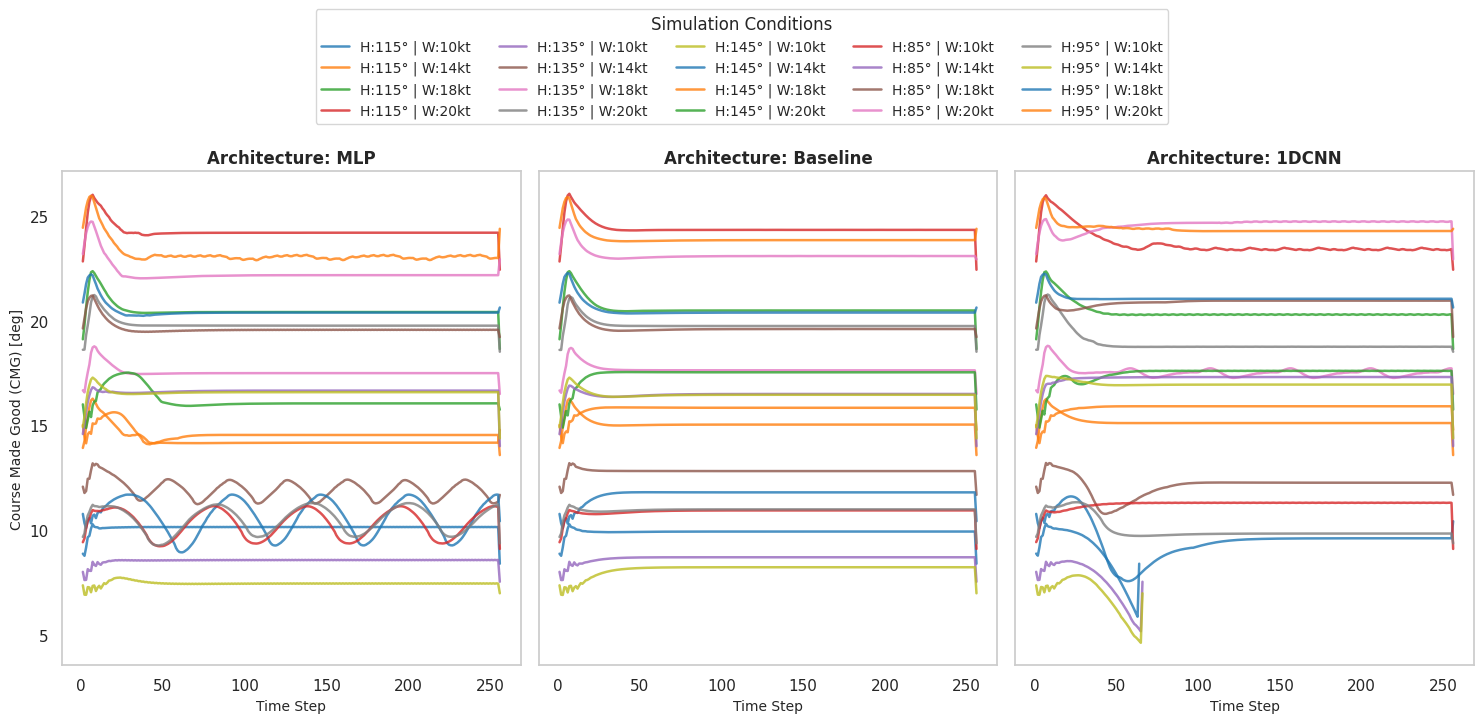

In [39]:
def plot_cmg(data_dirs):
    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
    palette = sns.color_palette("tab10", 9)
    
    for i, (model_name, folder) in enumerate(data_dirs.items()):
        ax = axes[i]
        csv_files = sorted(list(Path(folder).glob("*.csv")))
        

        for idx, file in enumerate(csv_files):
            df = pd.read_csv(file)
            cmg_col = 'cmg_deg' if 'cmg_deg' in df.columns else 'cmg_env'
            target = df['target_heading'].iloc[0]
            wind = df['wind_speed'].iloc[0]
            label = f"H:{target}° | W:{wind}kt"
            
            ax.plot(df['step'], df[cmg_col], color=palette[idx % 9], 
                    linewidth=1.8, alpha=0.8, label=label if i == 2 else None)
            
        ax.set_title(f"Architecture: {model_name}", fontweight='bold', fontsize=12)
        ax.set_xlabel("Time Step", fontsize=10)
        ax.grid(False)
        
        if i == 0:
            ax.set_ylabel("Course Made Good (CMG) [deg]", fontsize=10)


    handles, labels = axes[2].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1), 
                   ncol=5, fontsize='small', frameon=True, title="Simulation Conditions")

    plt.tight_layout() 
    

    output_path = "cmg_comparison_plot.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_path}")
    
    plt.show()


if __name__ == "__main__":
    plot_cmg(DATA_DIRS)

An architecture with high "fitness" will demonstrate a critically damped response reaching the steady-state $\phi_{\text{cmg}} \approx \psi_{\text{ref}}$ with minimal overshoot and oscillation regardless of the magnitude of the wind vector $V_{\text{wind}}$.

### Performance Summary Calculation

In order to calculate the average CMG, we should ignore the beginning of the episode. At the start, the boat is turning and accelerating. Including this would penalize the model's average speed and heading accuracy. By looking only at the last 200 steps (or **Steady state phase**), we measure the model's ability to maintain a stable  and maximum CMG once it has reached equilibrium.

In [128]:
STEADY_STATE_STEPS = 200

In [129]:
# --- Configuration ---
DATA_DIRS = {
    "MLP": Path("MLP"),
    "Baseline": Path("Baseline"),
    "1DCNN": Path("1DCNN")

}

In [136]:
def analyze_detailed_steady_state(data_dirs):
    all_results = []
    for arch, folder in data_dirs.items():
        folder = Path(folder)
        csv_files = list(folder.glob("*.csv"))
        for file in csv_files:
            df = pd.read_csv(file)
            if len(df) < 10: continue # Skip empty/failed runs
            
            cmg_col = 'cmg_deg' if 'cmg_deg' in df.columns else 'cmg_env'
            df_steady = df.tail(STEADY_STATE_STEPS)
                
            heading = df['target_heading'].iloc[0]
            wind = df['wind_speed'].iloc[0]
            heading = df['target_heading'].iloc[0]
                
            all_results.append({
                "Architecture": arch,
                "Heading": heading,
                "Wind": wind,
                "Target": heading,
                "Theta_Rad": np.deg2rad(heading),
                "Condition": f"H:{heading}° | W:{wind}kt",
                "Avg_CMG": df_steady[cmg_col].mean(),
                "Heading_Err": df_steady['heading_err'].abs().mean(),
                "Avg_XTE": df_steady['xte_error'].abs().mean()
            }) 
    return pd.DataFrame(all_results)

df = analyze_detailed_steady_state(DATA_DIRS)
df.head(5)

,Architecture,Heading,Wind,Target,Theta_Rad,Condition,Avg_CMG,Heading_Err,Avg_XTE
0,MLP,95,20,95,1.658063,H:95° | W:20kt,23.065747,4.861653,78.349640
1,MLP,115,18,115,2.007129,H:115° | W:18kt,20.419784,2.078258,28.756758
2,MLP,145,10,145,2.530727,H:145° | W:10kt,7.451787,8.152447,42.567937
3,MLP,145,18,145,2.530727,H:145° | W:18kt,14.185571,17.281095,178.758920
4,MLP,135,20,135,2.356194,H:135° | W:20kt,19.772244,2.098919,28.034551


In [137]:
def plot_per_case(summary_df):
    sns.set_theme(style="whitegrid", font_scale=1.0)
    plt.figure(figsize=(14, 7))

    palette = {"Baseline": "#95a5a6", "MLP": "#3498db", "1DCNN": "#e74c3c"}
    
    ax = sns.barplot(
        data=summary_df.sort_values(['Heading', 'Wind']), 
        x="Condition", 
        y="Avg_CMG", 
        hue="Architecture",
        palette=palette
    )
    
    plt.title("Steady State Comparison per Case", fontweight='bold', fontsize=14)
    plt.ylabel("Average CMG (knots)", fontsize=12)
    plt.xlabel("Simulation Condition", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title="Architecture", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig("per_case_sog_comparison.png", dpi=300)
    plt.show()

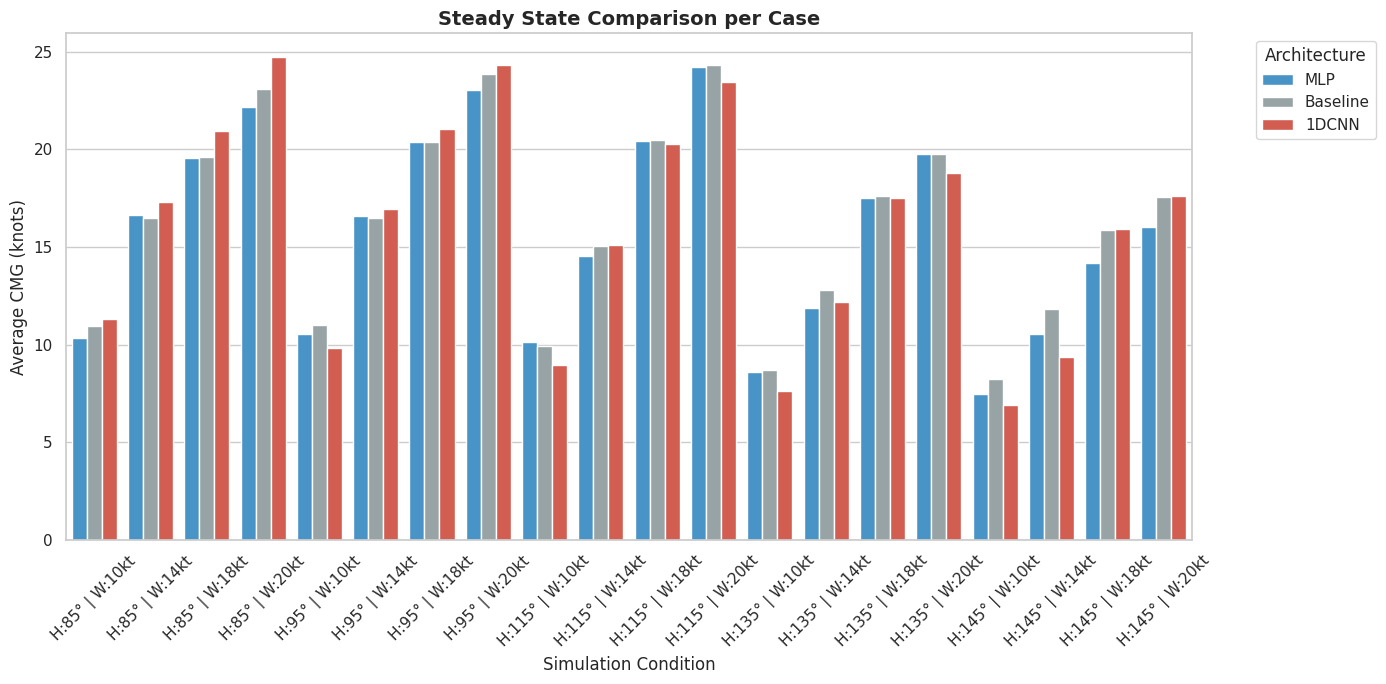

In [138]:
detailed_results = analyze_detailed_steady_state(DATA_DIRS)
detailed_results.to_csv("steady_state_per_case_comparison.csv", index=False)
plot_per_case(detailed_results)

## Polar Plots

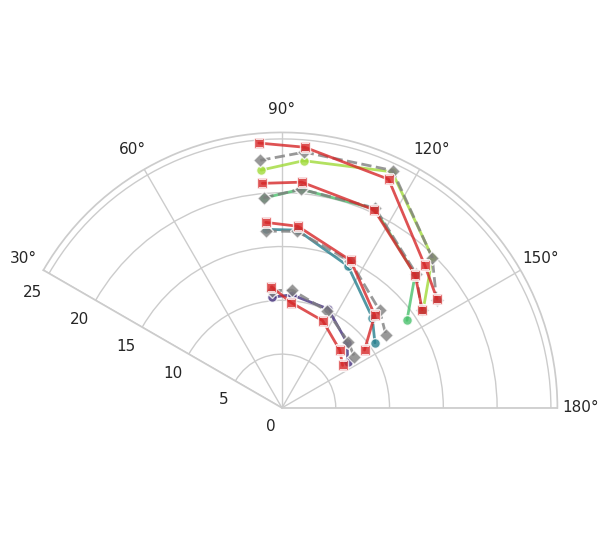

In [147]:

plt.figure(figsize=(8, 5.5))
ax = plt.subplot(111, projection='polar')

# Sailing convention: North (0°) is often top. 
# If 0° is your 'Upwind', keep zero_location('N')
ax.set_theta_zero_location('W') 
ax.set_theta_direction(-1) # Clockwise

unique_winds = [10, 12, 14, 16, 18, 20] 
colors = sns.color_palette("viridis", len(unique_winds))
wind_color_map = dict(zip(unique_winds, colors))

# Analyze all data first
detailed_results = analyze_detailed_steady_state(DATA_DIRS)

for arch in detailed_results['Architecture'].unique():
    arch_data = detailed_results[detailed_results['Architecture'] == arch]
    
    for wind in sorted(arch_data['Wind'].unique()):
        subset = arch_data[arch_data['Wind'] == wind].sort_values("Target")
        
        # Architecture Styling
        if arch == "1DCNN":
            color, marker, ls = "#D62728", 's', '-'
        elif arch == "MLP":
            color, marker, ls = wind_color_map.get(wind, 'blue'), 'o', '-'
        else:
            color, marker, ls = "#7F7F7F", 'D', '--'

        ax.plot(subset['Theta_Rad'], subset['Avg_CMG'], 
                marker=marker, linestyle=ls, color=color,
                linewidth=2.0, markersize=7, label=f"{arch} @ {wind}kt",
                alpha=0.8, markeredgecolor='white')

# Visual Polish
#ax.set_title("Performance Polar: SOG vs TWA", pad=30, fontweight='bold')
#ax.fill_between(np.radians([90, 140]), 0, 25, color='gray', alpha=0.1, label="Training Range")

# Zoom into the relevant sector
ax.set_thetamin(30)
ax.set_thetamax(180)
#ax.set_rlabel_position(160) 

#plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title="Policy & Wind")
plt.tight_layout()
plt.show()

# Off set plot

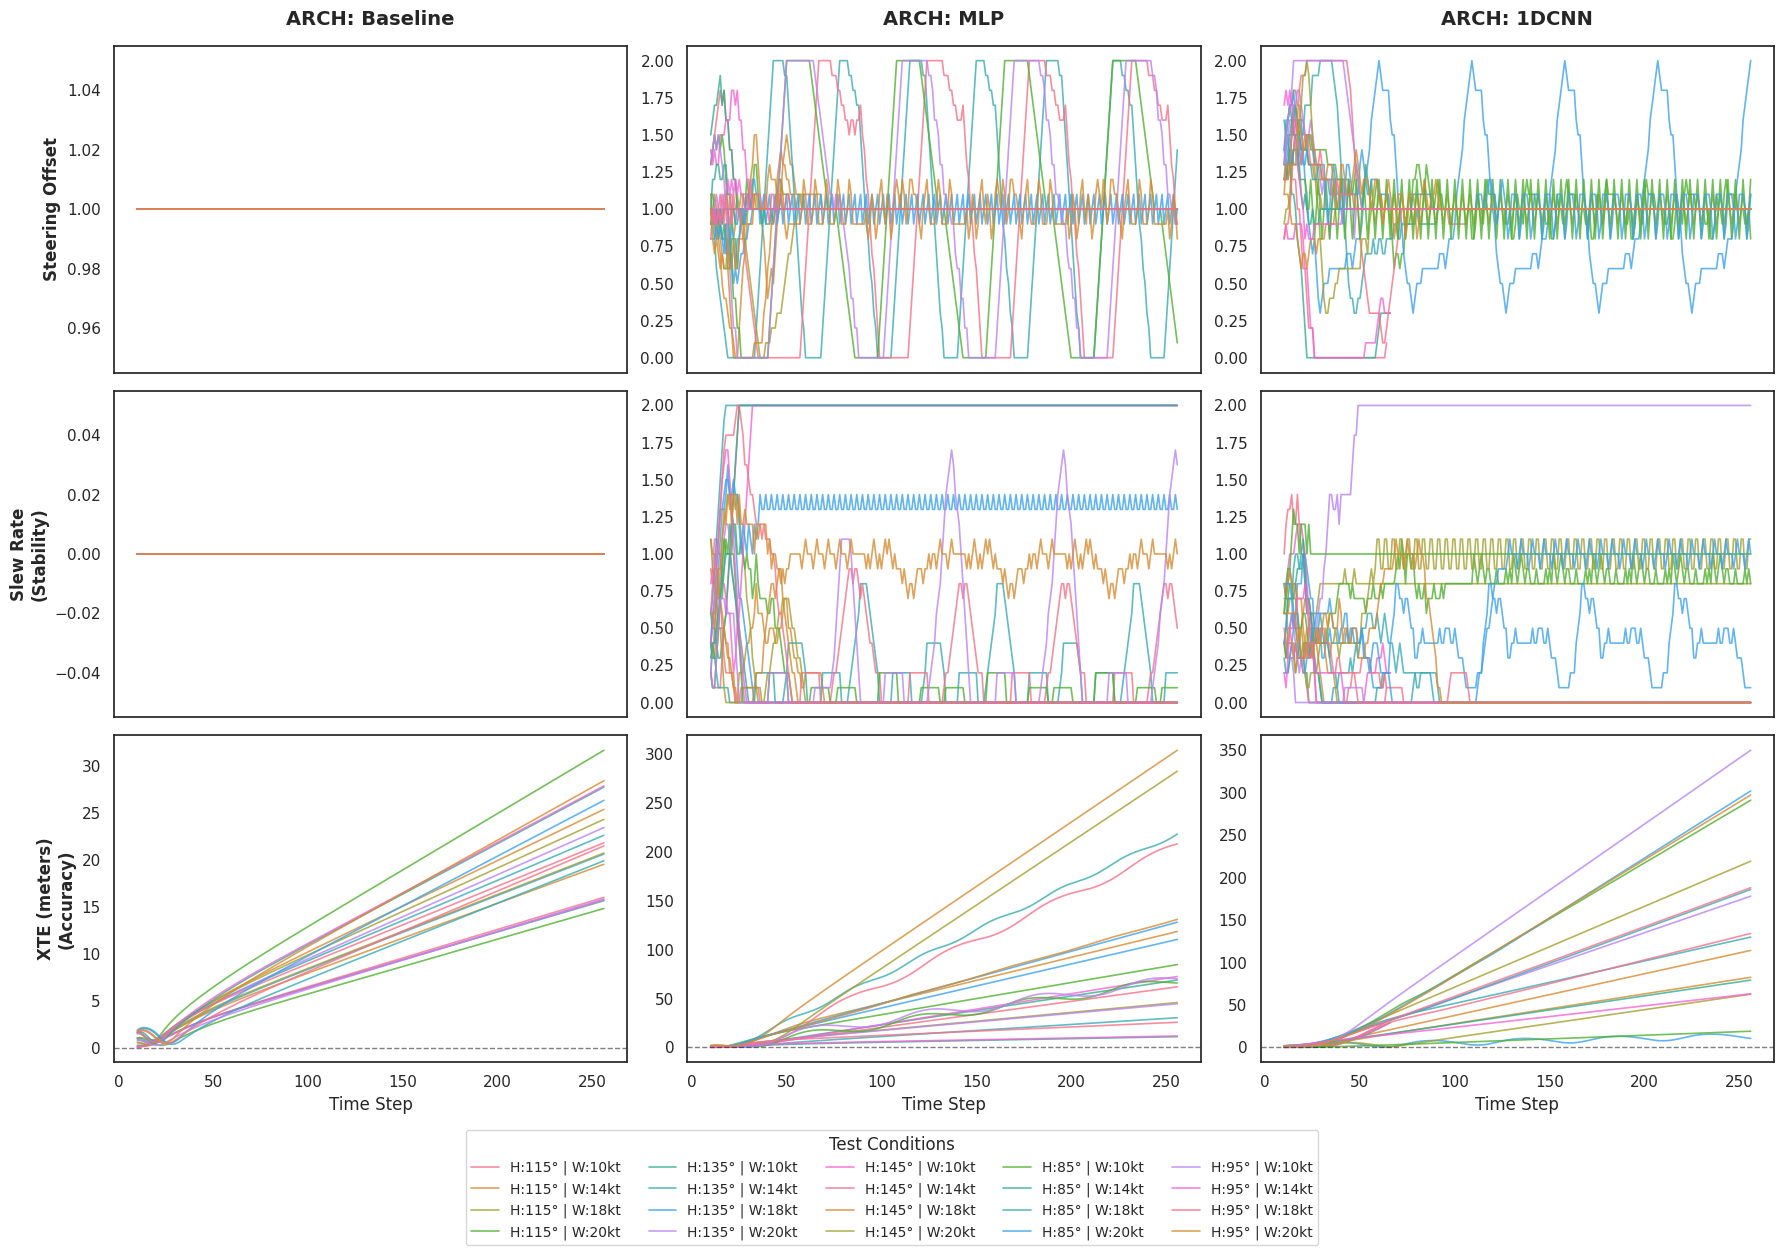

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Configuration ---
DATA_DIRS = {
    "Baseline": Path("Baseline"),
    "MLP": Path("MLP"),
    "1DCNN": Path("1DCNN")
}

def plot_performance_dashboard(data_dirs):
    sns.set_theme(style="white")
    # 3 Rows: Offset, Slew Rate, and Cross-Track Error
    # 3 Columns: One for each architecture
    fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
    palette = sns.color_palette("husl", 9)
    
    for i, (model_name, folder) in enumerate(data_dirs.items()):
        if not folder.exists(): continue
        csv_files = sorted(list(folder.glob("*.csv")))
        
        for idx, file in enumerate(csv_files):
            df = pd.read_csv(file)
            
            # Apply Smoothing (Moving Average of 15 steps)
            window = 10
            df['offset_smooth'] = df['action_offset'].rolling(window=window).mean()
            df['slew_smooth'] = df['slew_rate'].rolling(window=window).mean()
            df['xte_smooth'] = df['xte_error'].rolling(window=window).mean()
            
            label = f"H:{df['target_heading'].iloc[0]}° | W:{df['wind_speed'].iloc[0]}kt"
            color = palette[idx % 9]
            
            # Row 0: Steering Action Offset
            axes[0, i].plot(df['step'], df['offset_smooth'], color=color, linewidth=1.2, alpha=0.8)
            
            # Row 1: Stability (Slew Rate)
            axes[1, i].plot(df['step'], df['slew_smooth'], color=color, linewidth=1.2, alpha=0.8)
            
            # Row 2: Path Accuracy (XTE)
            axes[2, i].plot(df['step'], df['xte_smooth'], color=color, linewidth=1.2, alpha=0.8, 
                           label=label if i == 2 else None)

        # Titles for the top row (Architectures)
        axes[0, i].set_title(f"ARCH: {model_name}", fontweight='bold', fontsize=14, pad=15)
        axes[2, i].set_xlabel("Time Step")

    # Y-Axis Labels for the leftmost column
    axes[0, 0].set_ylabel("Steering Offset", fontweight='bold')
    axes[1, 0].set_ylabel("Slew Rate\n(Stability)", fontweight='bold')
    axes[2, 0].set_ylabel("XTE (meters)\n(Accuracy)", fontweight='bold')

    # Legend placement
    handles, labels = axes[2, 2].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
               ncol=5, fontsize='small', frameon=True, title="Test Conditions")

    # Add reference lines for XTE (Zero is ideal)
    for ax in axes[2, :]:
        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig("performance_dashboard.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    plot_performance_dashboard(DATA_DIRS)